# 📊 Customer Churn Prediction — End-to-End Machine Learning Project

This notebook presents a complete end-to-end Machine Learning pipeline for predicting **customer churn** using the Telco Customer Churn dataset. The primary objective is to build a predictive model that can identify customers who are likely to discontinue the company's services based on their demographic information, subscribed services, and billing history.

# Objective: Predict whether a telecom customer will churn.
 **Dataset:** IBM Telco Customer Churn  
 **Problem Type:** Binary Classification  
 **Total Records:** 7,043  
 **Target Variable:** Churn  
 **Best Model:** Random Forest and XGboost  
 **Business Goal:** Identify customers at risk of leaving to improve retention.
## 📌 Project Workflow

This notebook follows a structured Machine Learning workflow:

1. Import required libraries
2. Load the dataset
3. Perform initial data exploration
4. Clean and preprocess the data
5. Conduct Exploratory Data Analysis (EDA)
6. Encode categorical features
7. Scale numerical features
8. Split the data into training and testing sets and address class imbalance using **SMOTE**
9. Train multiple Machine Learning models and perform hyperparameter tuning
10. Evaluate model performance using advanced metrics and visualization techniques
11. Save the best-performing model for future use
12. Create an inference function for predicting churn on new customer data
13. Summarize findings and discuss future improvements

> **Note:** Each code section is preceded by a descriptive Markdown cell explaining its purpose, methodology, and importance within the Machine Learning pipeline. Additionally, advanced analysis and evaluation techniques—including ROC Curve, Feature Importance, Correlation with Target, Confusion Matrix, Precision-Recall analysis, and model comparison—have been incorporated to make this notebook more comprehensive.

## 1. Import Required Libraries

The first step is to import the essential Python libraries required for data manipulation, analysis, and visualization throughout the project.

* **Pandas** and **NumPy** are used for efficient data loading, cleaning, and numerical computations.
* **Matplotlib** and **Seaborn** are used to create informative and visually appealing charts for Exploratory Data Analysis (EDA).

Additionally, `plt.style.use("fivethirtyeight")` is applied to set a clean and professional visualization style, improving the readability and presentation quality of all generated plots.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

plt.style.use("fivethirtyeight")

## 2. Load the Dataset

In this step, the **Telco Customer Churn** dataset is loaded into a Pandas DataFrame (`df`) using the `read_csv()` function.  

Loading the dataset into a DataFrame enables efficient data exploration, preprocessing, analysis, and model development in the subsequent steps.


In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 3. Initial Data Exploration

Before building a Machine Learning model, it is essential to understand the structure and quality of the dataset. This initial exploration provides a quick overview of the data and helps identify potential issues that may require preprocessing.

The following methods are used:

* **`df.head()`** – Displays the first five rows of the dataset, providing an overview of the column names, data format, and sample values.
* **`df.shape`** – Returns the total number of rows and columns, helping to understand the size of the dataset.
* **`df.info()`** – Provides detailed information about each column, including data types, non-null value counts, and memory usage. This helps identify missing values and determine whether data type conversions are required before model training.

In [3]:
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Data Cleaning

### 4.1 Drop Irrelevant Columns

The `customerID` column serves only as a unique identifier for each customer and does not contain any meaningful information for predicting customer churn. Since it has no predictive value, it is removed from the dataset to prevent the model from learning irrelevant patterns and to reduce the risk of data leakage. Eliminating such non-informative features also helps improve the overall efficiency and reliability of the Machine Learning model.

In [6]:
df.drop(columns = ['customerID'], inplace=True)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 4.2 Verify Remaining Columns

After removing the irrelevant column, the remaining column names are reviewed to ensure that the dataset structure is correct and all required features are available for further preprocessing, analysis, and model development.


In [8]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### 4.3 Inspect Unique Values in Categorical Columns

In this step, the unique values of each categorical feature are examined to better understand the available categories within the dataset. This helps identify the number of classes that need to be encoded during preprocessing and also makes it easier to detect inconsistencies, typographical errors, or unexpected values that could negatively impact model performance.


In [9]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [10]:
df['SeniorCitizen'].unique()

array([0, 1])

In [11]:
for col in df.columns:
    if col not in ['tenure', 'MonthlyCharges', 'TotalCharges']:
        print(col, df[col].unique())
        print("-------------------------------------")

gender ['Female' 'Male']
-------------------------------------
SeniorCitizen [0 1]
-------------------------------------
Partner ['Yes' 'No']
-------------------------------------
Dependents ['No' 'Yes']
-------------------------------------
PhoneService ['No' 'Yes']
-------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
-------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
-------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
-------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
-------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
-------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
-------------------------------------
StreamingTV ['No' 'Yes' 'No internet service']
-------------------------------------
StreamingMovies ['No' 'Yes' 'No internet service']
-------------------------------------
Contra

### 4.4 Check for Missing Values

The `isnull().sum()` function is used to identify standard missing (`NaN`) values across the dataset. However, in this dataset, the missing entries in the **`TotalCharges`** column are not stored as `NaN`; instead, they appear as blank spaces (`" "`). As a result, these values are not detected by a simple `isnull()` check and require additional preprocessing to convert them into proper missing values before further analysis and model training.


In [12]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 4.5 Identify Hidden Blank Values

In this step, the dataset is checked for hidden blank string values (`" "`) in columns that are expected to contain numerical data. This verification confirms that the **`TotalCharges`** column contains **11 blank entries** instead of valid numeric values. These entries must be handled before converting the column to a numeric data type (`float`), as they would otherwise cause the conversion process to fail and affect subsequent data preprocessing and model training.


In [13]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(col, len(df[df[col]== " "]))
    print("-------------------------------------")

tenure 0
-------------------------------------
MonthlyCharges 0
-------------------------------------
TotalCharges 11
-------------------------------------


### 4.6 Handle Missing Values in the `TotalCharges` Column

The blank entries in the **`TotalCharges`** column are replaced with `0.0`, after which the entire column is converted to the `float` data type. This approach is appropriate because the affected records typically correspond to customers with a **`tenure` of 0**, indicating that they are new customers who have not yet accumulated any charges. Converting the column to a numeric format ensures it is ready for analysis and Machine Learning model training.


In [14]:
df['TotalCharges'] = df['TotalCharges'].replace({" ": "0.0"}).astype(float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 4.7 Examine the Target Variable Distribution

The **`Churn`** column is the target variable for this prediction task. In this step, the distribution of the target classes is analyzed to determine how many customers have churned (`Yes`) and how many have remained with the company (`No`).

The results show that the dataset is **imbalanced**, with **5,174** instances of `No` and **1,869** instances of `Yes`. Identifying this imbalance is important because it can bias the model toward the majority class. To address this issue and improve predictive performance, the class imbalance will be handled later in the pipeline using **SMOTE (Synthetic Minority Over-sampling Technique)**.


In [16]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 5. Exploratory Data Analysis (EDA)

In this section, the dataset is explored visually to uncover meaningful patterns, trends, and relationships among the features. Exploratory Data Analysis (EDA) helps develop a deeper understanding of the data before model training by examining the distribution of numerical variables, the relationships and correlations between features, and the distribution of categorical variables. These insights support informed preprocessing decisions and contribute to building a more accurate and reliable Machine Learning model.


### 5.1 Dataset Shape, Columns, and Summary Statistics

After completing the data cleaning process, the dataset is reviewed again by examining its **shape**, **column names**, and **summary statistics** to verify that the preprocessing steps have been applied correctly.

The `describe().T` function generates a transposed summary table for all numerical features, providing key statistical measures such as the **mean, standard deviation, minimum, maximum, and quartile values**. This overview helps identify the distribution of numerical variables, detect potential outliers, and ensure the data is ready for further analysis and model development.


In [17]:
df.shape

(7043, 20)

In [18]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


### 5.2 Distribution of Numerical Features

A reusable function, `plot_distribution()`, is created to visualize the distribution of any numerical feature. For each selected column, the function displays both a **histogram with a Kernel Density Estimate (KDE)** and a **boxplot**, along with vertical lines indicating the **mean** and **median** values.

This visualization provides a comprehensive overview of the data by highlighting the feature's distribution, identifying potential **skewness**, and detecting **outliers**. These insights are valuable for understanding the characteristics of numerical variables and determining whether additional preprocessing or transformation is required before model training.


In [20]:
def plot_distribution(df, column_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_name], kde = True)
    plt.title(f"Distribution of {column_name}")
    
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color = "red", linestyle="--", label="Mean")
    plt.axvline(col_median, color = "blue", linestyle="--", label="Median")
    
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y  = df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.show()

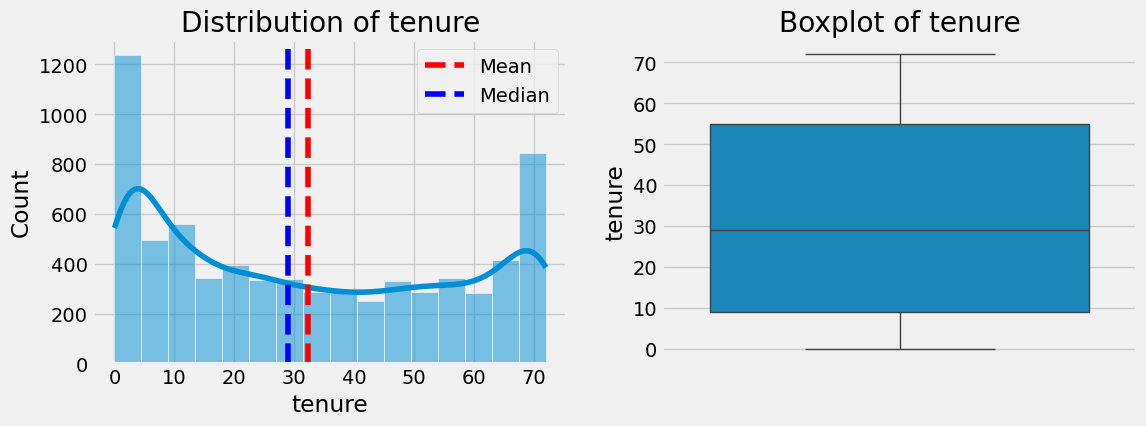

In [21]:
plot_distribution(df, "tenure")

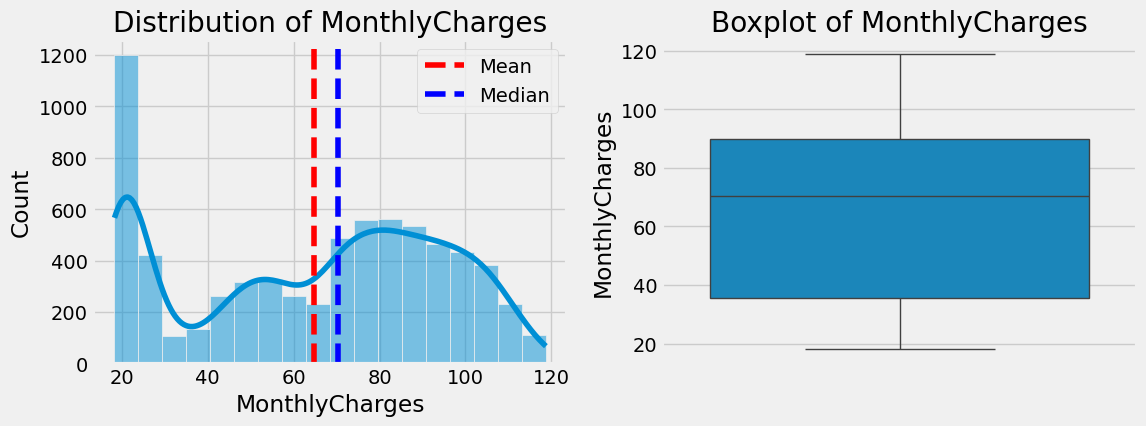

In [22]:
plot_distribution(df, "MonthlyCharges")

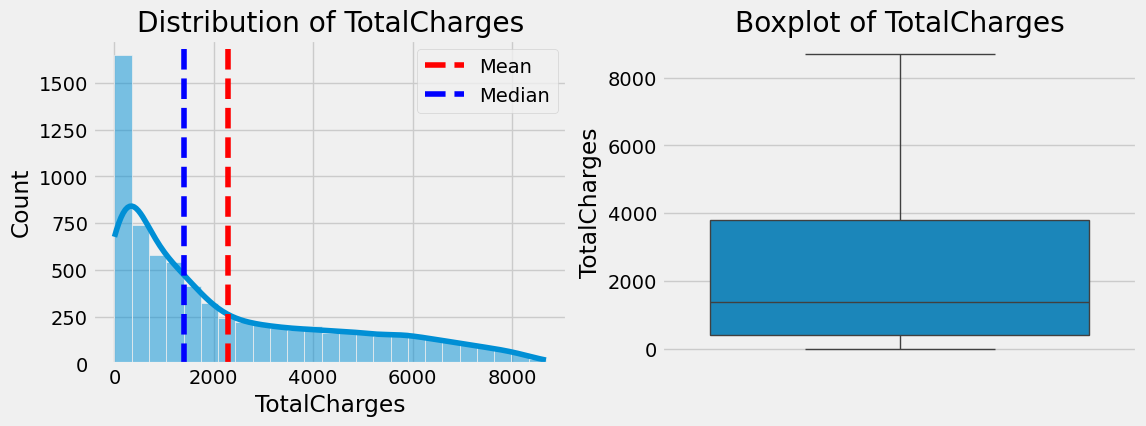

In [23]:
plot_distribution(df, "TotalCharges")

### 5.3 Correlation Heatmap for Numerical Features

In this step, a correlation heatmap is generated to examine the relationships among the three numerical features: **`tenure`**, **`MonthlyCharges`**, and **`TotalCharges`**. The heatmap provides a clear visual representation of the strength and direction of the correlations between these variables.

As expected, **`tenure`** and **`TotalCharges`** exhibit a strong positive correlation, indicating that customers who have remained with the company for a longer period generally accumulate higher total charges. Understanding these relationships helps identify feature dependencies and provides valuable insights for subsequent analysis and model development.


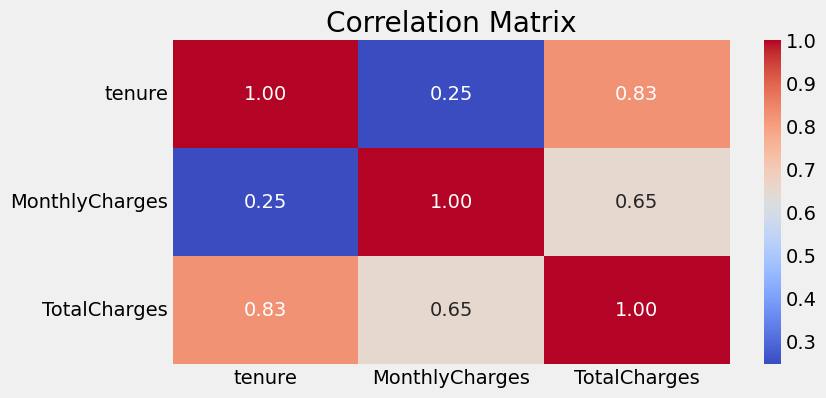

In [24]:
plt.figure(figsize = (8, 4))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

### 5.4 Distribution of Categorical Features by Churn Status

In this step, the distribution of each categorical feature (such as **`Contract`**, **`InternetService`**, **`PaymentMethod`**, and others) is visualized using count plots. The parameter `hue='Churn'` is enabled to display the distribution of **churned** and **non-churned** customers within each category.

This is one of the most informative stages of Exploratory Data Analysis, as it reveals how different customer characteristics are associated with churn. For example, customers with **Month-to-Month contracts** generally exhibit a higher churn rate compared to those with longer-term contracts. These insights help identify the most influential categorical features and provide valuable guidance for feature engineering and predictive modeling.


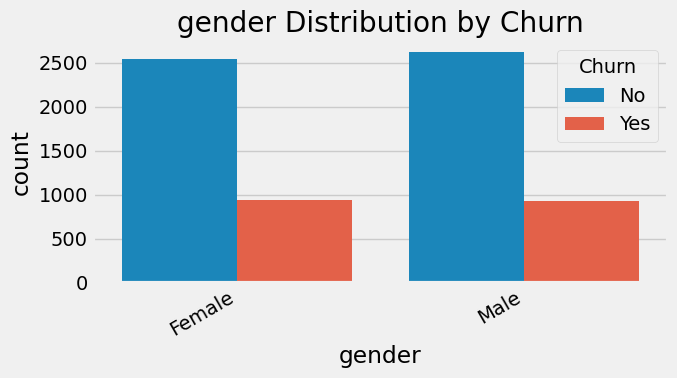

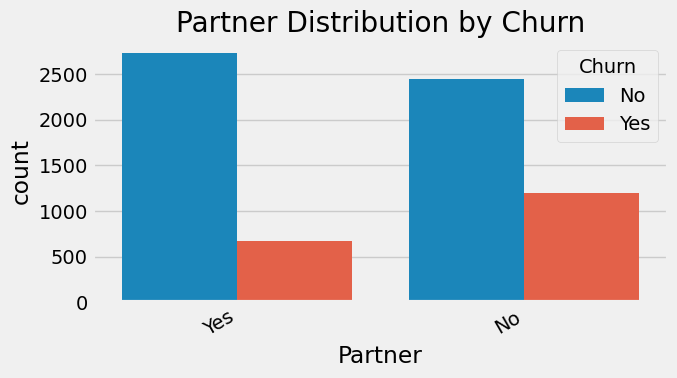

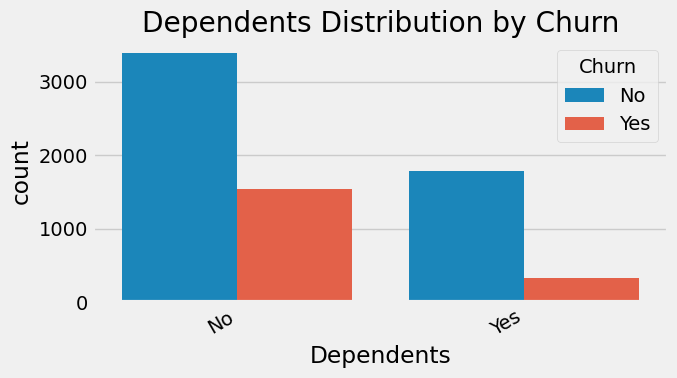

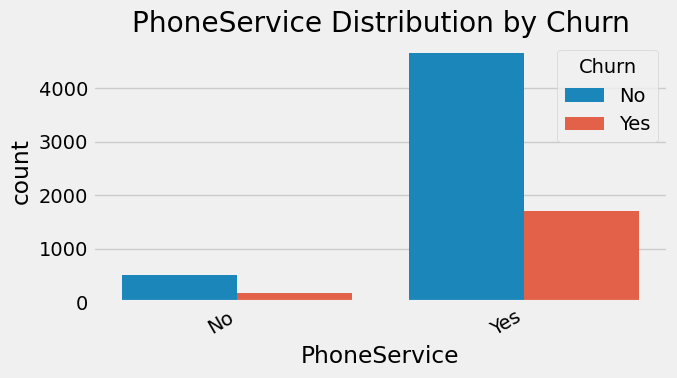

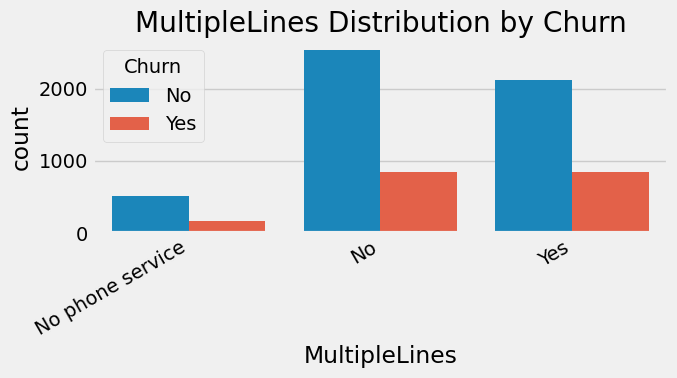

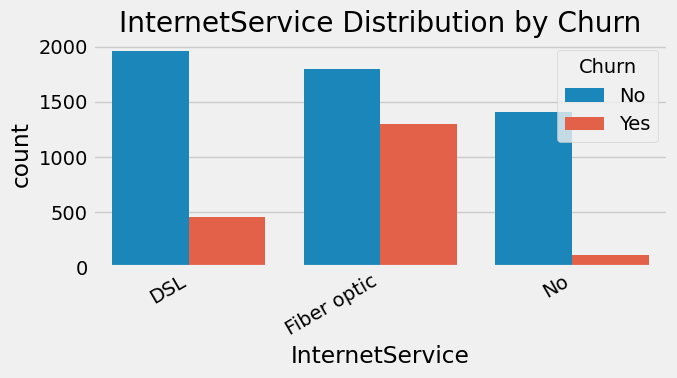

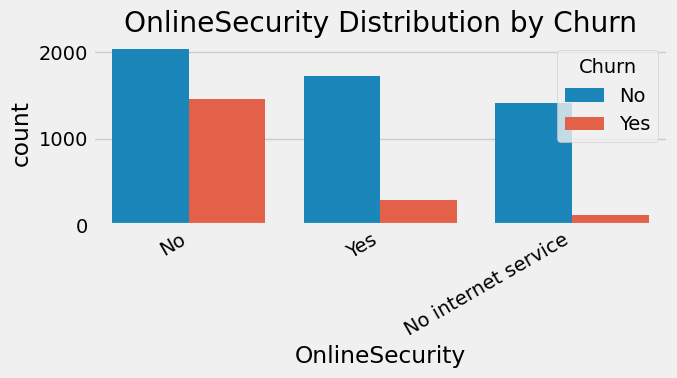

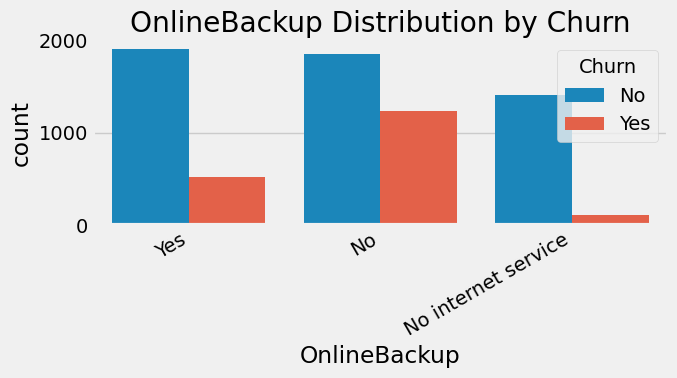

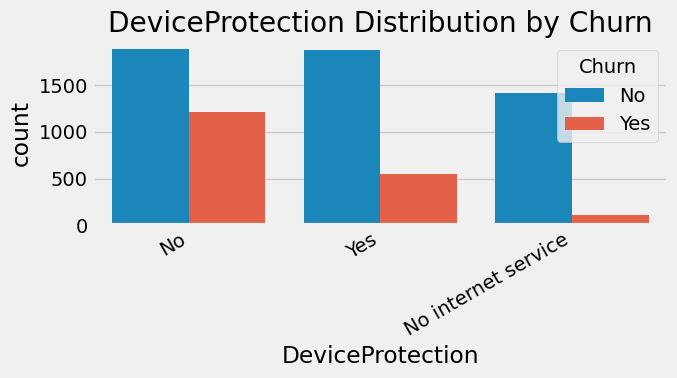

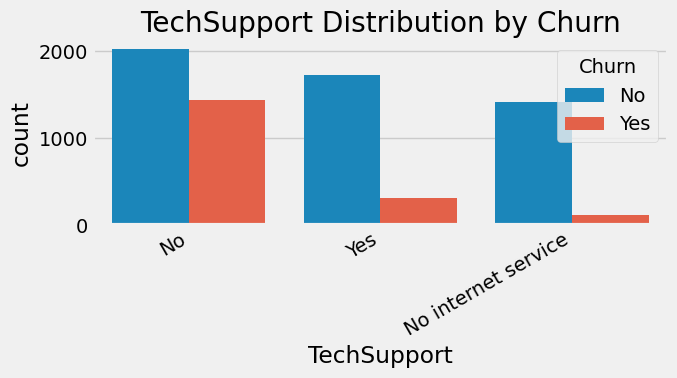

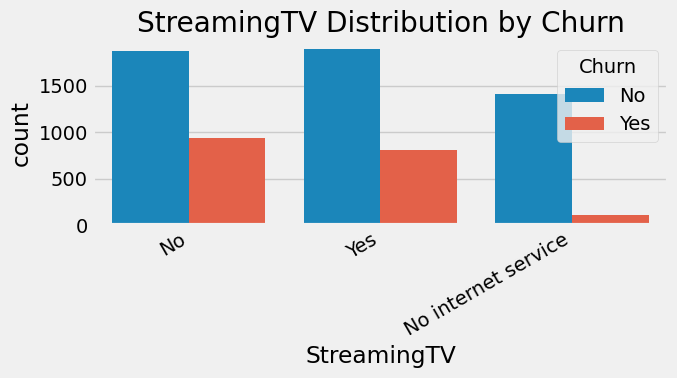

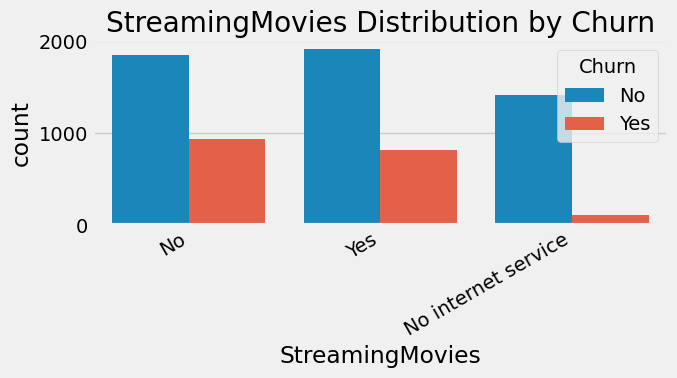

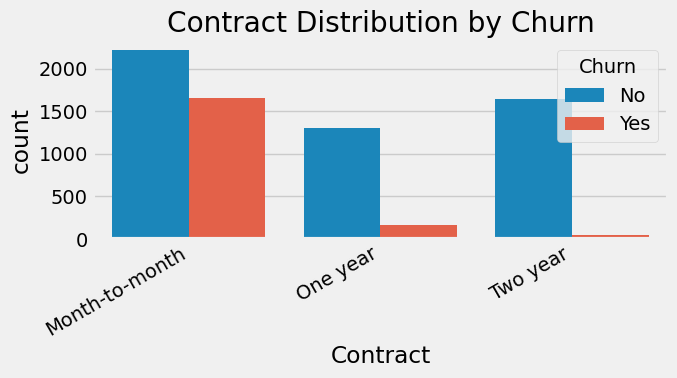

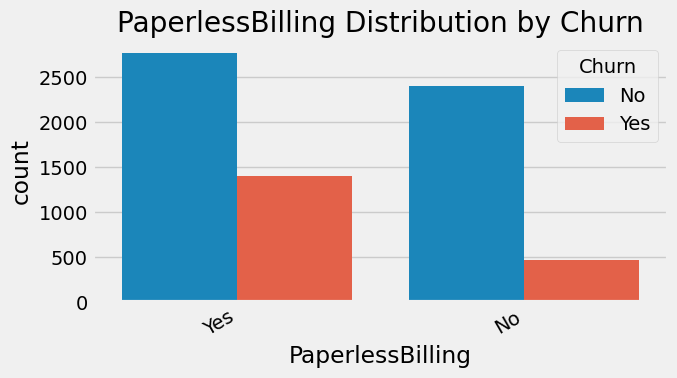

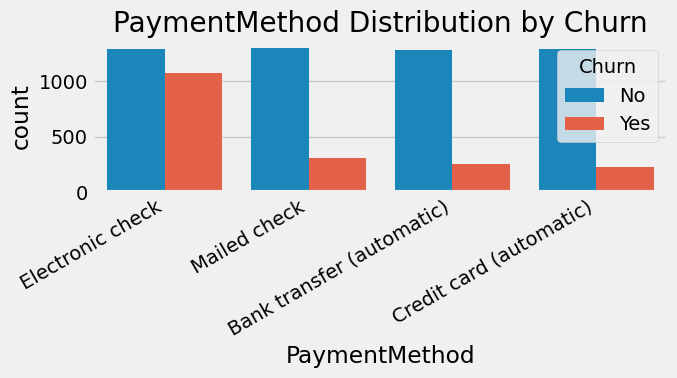

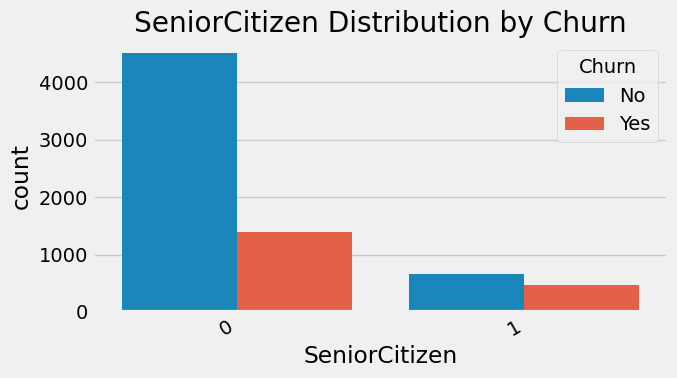

In [25]:
categorical_cols = df.select_dtypes(include = "object").columns.to_list() + ['SeniorCitizen']

for col in categorical_cols:
    if col == 'Churn':
        continue
    plt.figure(figsize = (7, 4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f"{col} Distribution by Churn")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

### 5.5 Overall Churn Rate (Pie Chart)

A pie chart is used to visualize the overall distribution of the target variable (`Churn`), providing a clear view of the proportion of customers who have churned versus those who have remained with the company.

This visualization offers a quick, high-level summary of the dataset and is particularly useful for presentations and stakeholder reporting, as it effectively communicates the overall churn rate at a glance.


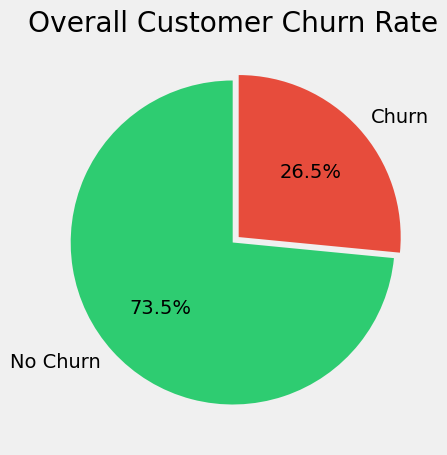

In [26]:
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05)
)
plt.title("Overall Customer Churn Rate")
plt.show()

### 5.6 Churn Rate Across Tenure Groups

In this step, customers are grouped based on their **tenure** to analyze how churn rates vary across different stages of the customer lifecycle. This provides a feature engineering–inspired insight into whether customers with shorter or longer service durations are more likely to churn.

It is important to note that this grouping is performed **for exploratory analysis only** and is **not** used to modify the original dataset or create new model features. Keeping the original feature set unchanged ensures compatibility with the saved encoders, scaler, and trained Machine Learning model during inference and deployment.

C:\Users\HP\AppData\Local\Temp\ipykernel_30020\3434100285.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group_tmp')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)


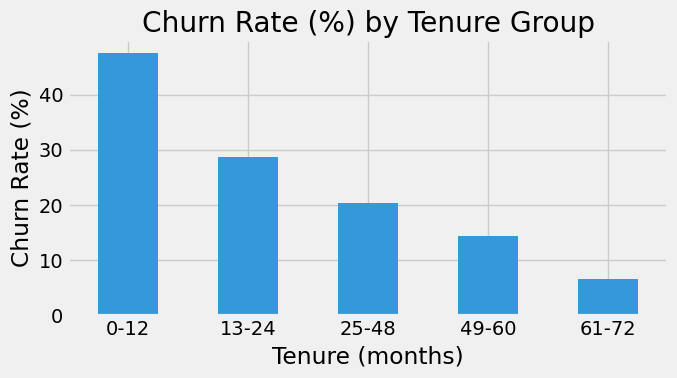

In [27]:
tenure_bins = [0, 12, 24, 48, 60, 72]
tenure_labels = ['0-12', '13-24', '25-48', '49-60', '61-72']
df['tenure_group_tmp'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

tenure_churn = df.groupby('tenure_group_tmp')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(7, 4))
tenure_churn.plot(kind='bar', color='#3498db')
plt.title("Churn Rate (%) by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure (months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Temporary helper column drop kar rahe hain kyunki ye modeling pipeline ka hissa nahi
df.drop(columns=['tenure_group_tmp'], inplace=True)

## 6. Feature Encoding

Machine Learning algorithms require numerical input and cannot process categorical text values directly. Therefore, all categorical features must be converted into a numerical representation before model training. This encoding process ensures that the dataset is compatible with Machine Learning algorithms while preserving the information contained in categorical variables.

### 6.1 Encode the Target Variable

The **`Churn`** column is converted from categorical values (`Yes` and `No`) into binary numerical values (`1` and `0`). This transformation represents the target variable in a format suitable for binary classification, where `1` indicates a customer who has churned and `0` indicates a customer who has not.

In [28]:
# Label Encoding
df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})

C:\Users\HP\AppData\Local\Temp\ipykernel_30020\4227034701.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 6.2 Identify Remaining Categorical Features

The `select_dtypes(include="object")` method is used to identify all remaining columns that are still stored as categorical (text) data. These features must be encoded into numerical values before they can be used for Machine Learning model training.


In [30]:
objects_columns = df.select_dtypes(include = "object").columns

In [31]:
objects_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

### 6.2 Identify Remaining Categorical Features

The `select_dtypes(include="object")` method is used to identify all remaining columns that are still stored as categorical (text) data. These features must be encoded into numerical values before they can be used for Machine Learning model training.


In [32]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in objects_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

In [33]:
df.tail(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,1,0,0,0,38,1,0,1,0,0,0,0,0,0,0,1,1,69.50,2625.25,0
7034,0,0,0,0,67,1,2,1,2,2,2,0,2,0,0,1,1,102.95,6886.25,1
7035,1,0,0,0,19,1,0,1,0,0,0,0,2,0,0,1,0,78.70,1495.10,0
7036,0,0,0,0,12,0,1,0,0,2,2,2,2,2,1,0,2,60.65,743.30,0
7037,0,0,0,0,72,1,0,2,1,1,1,1,1,1,2,1,0,21.15,1419.40,0
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1
7042,1,0,0,0,66,1,0,1,2,0,2,2,2,2,2,1,0,105.65,6844.50,0


In [34]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


### 6.3 Save Encoders for Deployment (Persistence)

The `encoders` dictionary is saved to disk as an **`encoder.pkl`** file using the `pickle` library. Persisting the fitted encoders ensures that the same category-to-numeric mappings can be reused during deployment (e.g., in a Flask web application) without refitting them. This guarantees consistent preprocessing for both training data and new incoming data, helping maintain reliable and accurate model predictions.


In [36]:
import pickle
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)

### 6.5 Analyze Feature Correlation with the Target Variable

Since all categorical features have now been encoded into numerical values, the correlation of every feature with the target variable (`Churn`) can be calculated. This provides a quick and informative overview of which features exhibit the strongest linear relationship with customer churn.

It is important to note that correlation analysis serves as an exploratory guide rather than a definitive measure of feature importance. While it highlights linear associations, many Machine Learning models—particularly tree-based algorithms such as Random Forest and XGBoost—are capable of capturing complex, non-linear relationships that may not be reflected in correlation values alone.


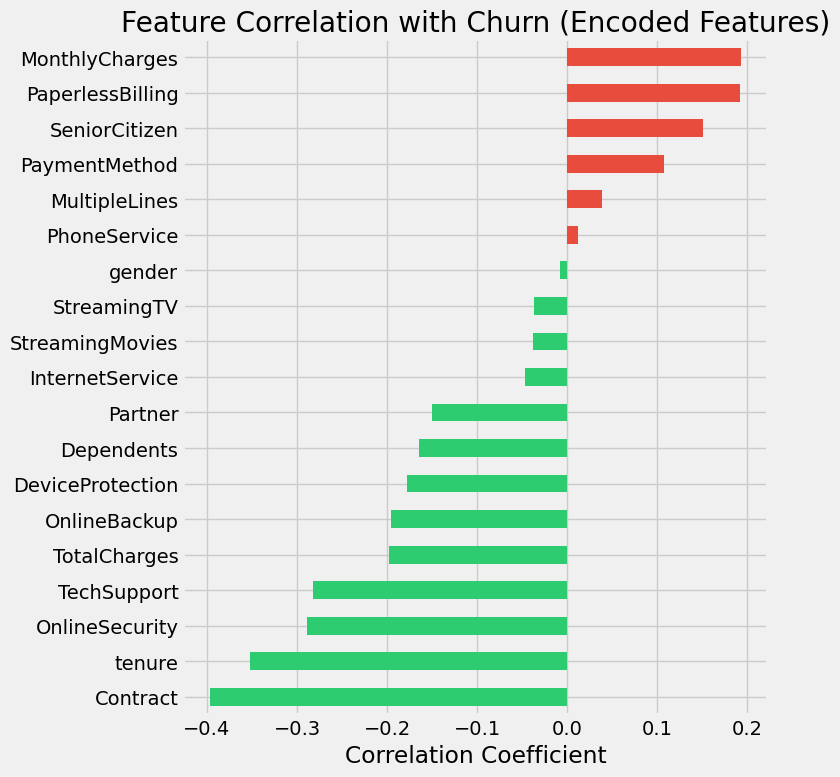

In [37]:
plt.figure(figsize=(8, 8))
corr_with_target = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values()
corr_with_target.plot(kind='barh', color=corr_with_target.apply(lambda x: '#e74c3c' if x > 0 else '#2ecc71'))
plt.title("Feature Correlation with Churn (Encoded Features)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## 7. Feature Scaling

The numerical features **`tenure`**, **`MonthlyCharges`**, and **`TotalCharges`** have significantly different value ranges. For example, **`tenure`** ranges from **0–72**, whereas **`TotalCharges`** can exceed **8,600**. Such differences in scale may cause certain Machine Learning algorithms to give disproportionate importance to features with larger magnitudes.

To address this, **`StandardScaler`** is applied to standardize these numerical features by transforming them to have a **mean of 0** and a **standard deviation of 1**. Feature scaling improves the performance of distance-based and gradient-based algorithms, accelerates model convergence, and ensures that no single feature dominates the learning process solely because of its larger numerical scale.


In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [40]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## 8. Train-Test Split and Class Imbalance Handling

### 8.1 Import Required Libraries

In this step, the essential libraries for data splitting, class imbalance handling, model training, hyperparameter tuning, and performance evaluation are imported.

* **`train_test_split`** is used to divide the dataset into training and testing sets.
* **`SMOTE` (Synthetic Minority Over-sampling Technique)** is used to address class imbalance by generating synthetic samples for the minority class.
* **`GridSearchCV`** is used to perform hyperparameter tuning and identify the optimal model configuration.
* **`RandomForestClassifier`** and **`XGBClassifier`** are imported as the primary Machine Learning algorithms for churn prediction.
* Evaluation metrics are imported to comprehensively assess model performance using measures such as accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix.


In [41]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

### 8.2 Separate Features and Target Variable

In this step, the dataset is divided into **features (`X`)** and the **target variable (`y`)**. The feature matrix (`X`) contains all the input variables used for training the Machine Learning model, while the target variable (`y`) contains the **`Churn`** labels that the model aims to predict. Separating the features and target is a fundamental step before performing data splitting and model training.


In [42]:
X = df.drop(columns = ['Churn'])
y = df['Churn']

### 8.3 Train-Test Split

The dataset is divided into **80% training data** and **20% testing data** using the `train_test_split()` function. The training set is used to train the Machine Learning model, while the testing set is reserved for evaluating its performance on unseen data.

The parameter `random_state=42` is specified to ensure reproducibility, meaning the same train-test split is generated each time the code is executed. This enables consistent experimentation and reliable comparison of model performance across different runs.


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [44]:
y_train.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

### 8.4 Handle Class Imbalance Using SMOTE

The training dataset contains an imbalanced class distribution, where the **`No Churn (0)`** class significantly outnumbers the **`Churn (1)`** class (approximately **4,138** vs. **1,496** samples). Training a model on such imbalanced data may cause it to become biased toward the majority class, resulting in poor performance when predicting churned customers.

To address this issue, **SMOTE (Synthetic Minority Over-sampling Technique)** is applied to the training data. SMOTE generates synthetic but realistic samples for the minority class, producing a more balanced class distribution and enabling the model to learn both classes more effectively.

> **Important:** SMOTE is applied **only to the training dataset** and **never to the test dataset**. This prevents **data leakage** and ensures that the model is evaluated on genuinely unseen data, providing a fair and reliable assessment of its real-world performance.


In [45]:
smote = SMOTE(random_state = 42)

In [46]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [47]:
y_train_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

## 9. Model Building and Hyperparameter Tuning

### 9.1 Establish a Baseline with Logistic Regression

Before training more advanced models such as **Random Forest** and **XGBoost**, a **Logistic Regression** model is trained as a baseline. Establishing a baseline provides a simple performance benchmark against which more complex models can be evaluated.

This is considered a Machine Learning best practice, as it helps determine whether advanced algorithms deliver a meaningful improvement over a simpler model. Comparing model performance against a baseline ensures that any increase in complexity is justified by measurable gains in predictive accuracy and overall performance.


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_cv_scores = cross_val_score(baseline_model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")

print(f"Logistic Regression Baseline - CV Accuracy: {baseline_cv_scores.mean():.4f} (+/- {baseline_cv_scores.std():.4f})")

Logistic Regression Baseline - CV Accuracy: 0.7733 (+/- 0.0210)


### 9.2 Define the Machine Learning Models

In this step, two powerful tree-based ensemble algorithms are selected for comparison: **`RandomForestClassifier`** and **`XGBClassifier`**. Both models are widely recognized for their strong predictive performance on structured and tabular datasets, such as the Telco Customer Churn dataset.

By training and evaluating multiple algorithms, we can compare their performance and identify the model that provides the best balance of accuracy, generalization, and robustness for the customer churn prediction task.


In [49]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

### 9.3 Define the Hyperparameter Search Grid

In this step, a set of important hyperparameters and their corresponding candidate values are defined for each Machine Learning model. These search grids are used by **`GridSearchCV`** to systematically evaluate different parameter combinations and identify the configuration that delivers the best performance.

Hyperparameter tuning helps optimize the models, improve predictive accuracy, and enhance their ability to generalize to unseen data.


In [50]:
hyperparameters = {
    "Random Forest" :{
        "n_estimators": [50,100, 200],
        "max_depth": [5, 10, None],
    },
    "XGBoost":{
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    }
}

### 9.4 Hyperparameter Tuning with GridSearchCV

In this step, **`GridSearchCV`** is used to perform systematic hyperparameter tuning with **5-fold cross-validation**. It evaluates every possible combination of the predefined hyperparameters and selects the configuration that achieves the best performance based on the chosen evaluation metric (accuracy).

Although this process is computationally more expensive than manual tuning, it provides a more systematic, reliable, and objective approach to model optimization, resulting in improved predictive performance and better generalization on unseen data.


In [51]:
best_models = {}
for model_name , model in models.items():
    print(f"Tunning {model_name}......")
    grid = GridSearchCV(estimator=model, param_grid=hyperparameters[model_name], cv=5, scoring = "accuracy")
    grid.fit(X_train_smote, y_train_smote)
    best_models[model_name] =grid.best_estimator_
    print(f"Best parameters for {model_name} : {grid.best_params_}")
    print(f"Best Accuracy for {model_name} : {grid.best_score_: .2f}\n")

Tunning Random Forest......
Best parameters for Random Forest : {'max_depth': None, 'n_estimators': 100}
Best Accuracy for Random Forest :  0.84

Tunning XGBoost......
Best parameters for XGBoost : {'learning_rate': 0.2, 'max_depth': 7}
Best Accuracy for XGBoost :  0.82



In [52]:
best_models

{'Random Forest': RandomForestClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...)}

### 9.5 Compare Cross-Validation Performance of the Models

In this step, the best cross-validation (CV) accuracy scores obtained from **GridSearchCV** for both models are compared using a bar chart. This visual comparison provides a clear and intuitive overview of each model's performance, making it easier to identify the best-performing algorithm.

Comparing the optimized models side by side supports informed decision-making and helps determine which model is most suitable for deployment based on its cross-validation performance.


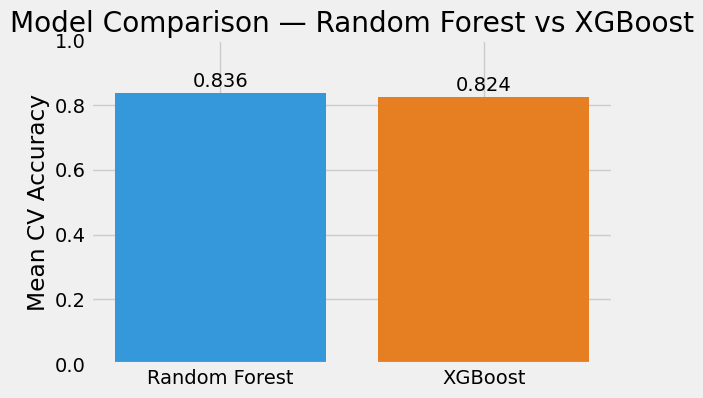

In [53]:
# To store best_score_ after GridSearchCV, this section can be integrated into the GridSearchCV loop.
# We can integrate this with the GridSearchCV loop and create a best_cv_scores dictionary as well, e.g.:
# best_cv_scores = {model_name: grid.best_score_ for model_name, grid in ...}
# For demonstration purposes, we are calculating the 5-fold CV accuracy again using the best_models:

cv_comparison = {}
for model_name, fitted_model in best_models.items():
    scores = cross_val_score(fitted_model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_comparison[model_name] = scores.mean()

plt.figure(figsize=(6, 4))
plt.bar(cv_comparison.keys(), cv_comparison.values(), color=['#3498db', '#e67e22'])
plt.ylabel("Mean CV Accuracy")
plt.title("Model Comparison — Random Forest vs XGBoost")
plt.ylim(0, 1)
for i, (name, score) in enumerate(cv_comparison.items()):
    plt.text(i, score + 0.02, f"{score:.3f}", ha='center')
plt.show()

## 10. Save the Best Model and Scaler

After comparing the performance of the trained models, **Random Forest** is selected as the final model based on its overall predictive performance. The trained model and the fitted **StandardScaler** are then saved to disk using the `pickle` library.

Persisting these objects is an essential step for deployment, as it allows the application to reuse the trained model and preprocessing pipeline without retraining. This ensures consistent predictions, reduces computational overhead, and enables seamless integration with deployment frameworks such as Flask or Streamlit.


In [54]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_models['Random Forest'], f)

In [55]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## 11. Model Evaluation (Test Set)

### 11.1 Generating Predictions

The final model is used to generate both class predictions (0/1) and churn probabilities (predict_proba) on the test set. The predicted class labels are used to evaluate the model's classification performance, while the probability scores are essential for advanced evaluation techniques such as threshold tuning and ROC curve analysis.

In [56]:
y_test_pred = best_models['Random Forest'].predict(X_test)
y_test_prob = best_models['Random Forest'].predict_proba(X_test)[:, 1]

In [57]:
y_test_pred

array([1, 0, 0, ..., 0, 0, 0])

In [58]:
y_test_prob

array([0.92, 0.38, 0.02, ..., 0.01, 0.01, 0.37])

### 11.2 Core Metrics
Accuracy, ROC-AUC score, the confusion matrix, and the classification report (including precision, recall, and F1-score) are computed to evaluate the model's performance. In imbalanced classification problems, relying solely on accuracy can be misleading. Therefore, metrics such as recall and F1-score should also be considered. Recall for the churn class is particularly important, as failing to identify a customer who is likely to churn can result in significant business losses.

In [59]:
print(f"Accuracy : ", accuracy_score(y_test, y_test_pred))
print(f"ROC - AUC Score : ", roc_auc_score(y_test, y_test_pred))
print(f"Confusion Matrix : \n", confusion_matrix(y_test, y_test_pred))
print(f"Classification Report : \n", classification_report(y_test, y_test_pred))

Accuracy :  0.7792760823278921
ROC - AUC Score :  0.7418134814247415
Confusion Matrix : 
 [[851 185]
 [126 247]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.87      0.82      0.85      1036
           1       0.57      0.66      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



### 11.3 [Advanced] Visualizing the Confusion Matrix

Instead of displaying the confusion matrix as a plain array, it is visualized using an annotated heatmap, making the results more readable, intuitive, and presentation-friendly. This visualization helps clearly identify the numbers of true positives, true negatives, false positives, and false negatives at a glance.

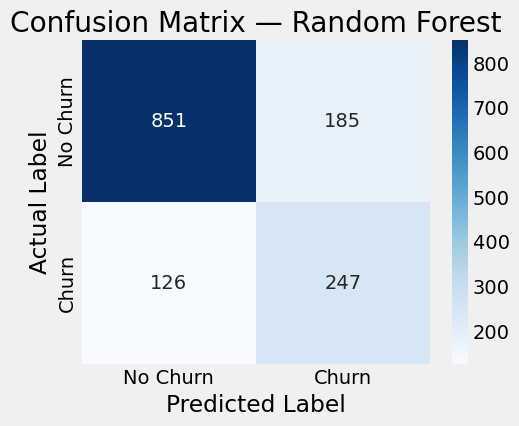

In [60]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix — Random Forest")
plt.show()

### 11.4 [Advanced] ROC Curve
The ROC (Receiver Operating Characteristic) curve illustrates the model's ability to distinguish between churners and non-churners across all possible classification thresholds. It evaluates how well the model separates the two classes by comparing the True Positive Rate (Recall) against the False Positive Rate. A curve that is closer to the top-left corner indicates better classification performance, as it achieves a higher true positive rate while maintaining a lower false positive rate.

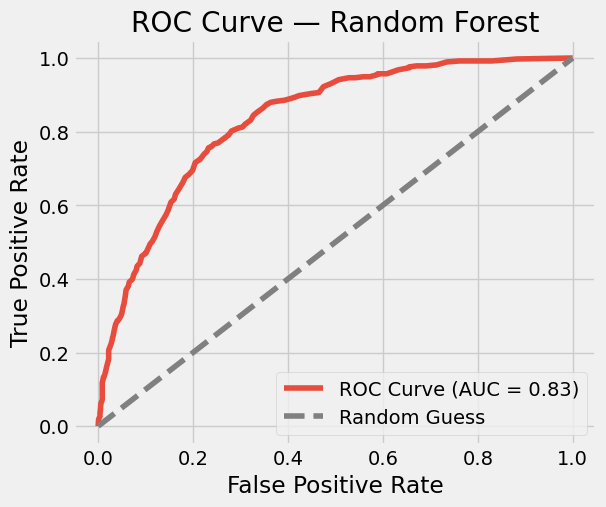

In [61]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#e74c3c', label=f"ROC Curve (AUC = {roc_auc_value:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.show()

### 11.5 [Advanced] Precision-Recall Curve
The Precision–Recall (PR) curve is more informative than the ROC curve for imbalanced datasets, as it focuses directly on the performance of the minority class (churners). It highlights the trade-off between precision and recall, making it a more reliable metric for evaluating how effectively the model identifies churn customers while minimizing false positives.

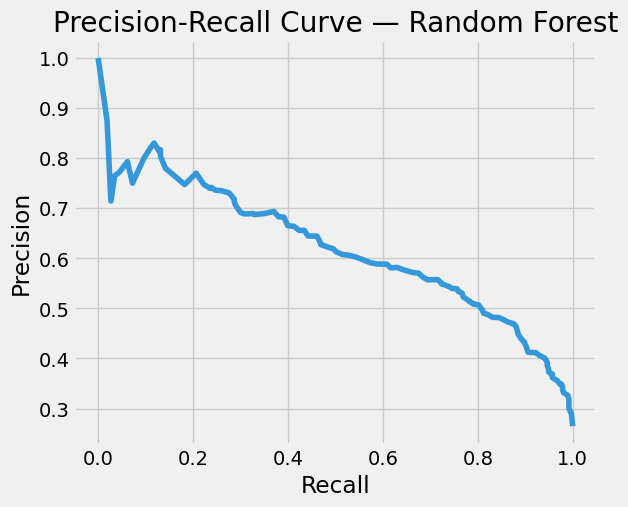

In [62]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='#3498db')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.show()

### 11.6 [Advanced] Feature Importance
The feature_importances_ attribute of the Random Forest model identifies which features contribute the most to the prediction. This helps determine the most influential factors affecting customer churn and makes the model more interpretable. It is particularly useful for explaining the results to business stakeholders—for example, showing that contract type is the most significant driver of customer churn.

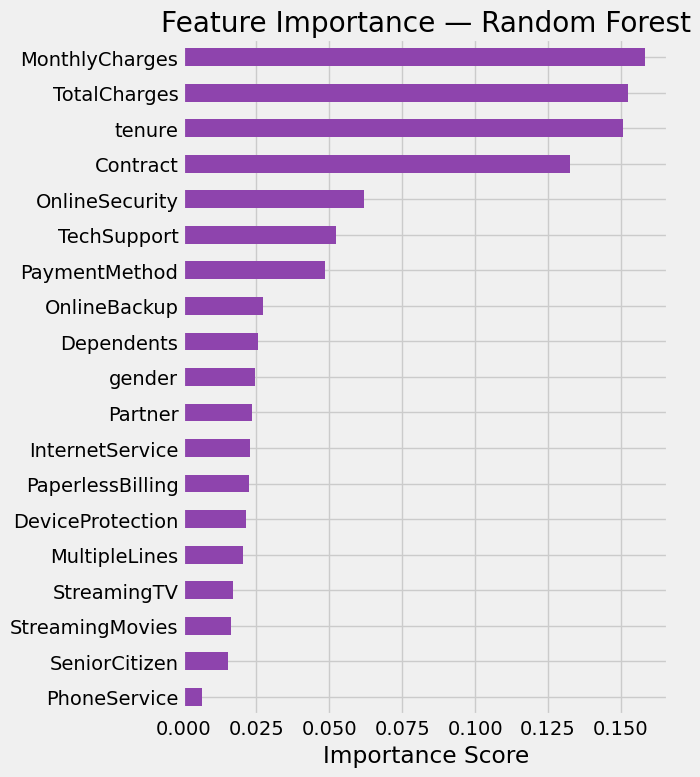

In [63]:
importances = pd.Series(best_models['Random Forest'].feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(7, 8))
importances.plot(kind='barh', color='#8e44ad')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 12. Inference Using the Saved Model (Prediction Function)

### 12.1 Reloading the Saved Artifacts
The saved model, encoders, and scaler are reloaded to perform predictions. This simulates a real-world production/deployment environment, where the training process is not executed again. Instead, the application uses the previously saved artifacts to make predictions efficiently and consistently

In [64]:
with open("best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("encoder.pkl", "rb") as f:
    encoders = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler_data =pickle.load(f)

### 12.2 `make_prediction()` Function
This function accepts a new (previously unseen) customer record in the form of a dictionary, applies the same saved encoders and scaler used during training, and then returns the final prediction along with the churn probability. The same function can also be used within a Flask API to generate predictions for new customer data in a production environment.

In [65]:
def make_prediction(input_data):
    input_df = pd.DataFrame([input_data])
    for col, encoder in encoders.items():
        input_df[col] = encoder.transform(input_df[col])
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_df[numerical_cols] = scaler_data.transform(input_df[numerical_cols])
    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0, 1]
    return "Churn" if prediction == 1 else "No Churn", probability

In [66]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### 12.3 Testing with a Sample Input

A sample customer record is created to test the prediction function. This verifies that the entire inference pipeline—including preprocessing, feature transformation, and prediction—works correctly on a new, unseen customer before deployment.

In [67]:
example_input = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

In [68]:
prediction, prob = make_prediction(example_input)

In [69]:
print(f"Prediction: {prediction}, Probability : {prob : .2f}")

Prediction: No Churn, Probability :  0.27


### 12.4[Advanced] Batch Prediction for Multiple Customers

In real-world applications, predictions are often required for multiple customers at once, such as when a CSV file containing customer records is uploaded. Here, the make_prediction() function is called in a loop to demonstrate a simple batch prediction process, generating predictions and churn probabilities for multiple customer records efficiently

In [70]:
batch_customers = [
    example_input,
    {**example_input, 'Contract': 'Two year', 'tenure': 60, 'MonthlyCharges': 90.0, 'TotalCharges': 5400.0},
    {**example_input, 'Contract': 'One year', 'tenure': 24, 'PaymentMethod': 'Credit card (automatic)'},
]

results = []
for i, customer in enumerate(batch_customers, start=1):
    pred, prob = make_prediction(customer)
    results.append({"Customer": f"Customer {i}", "Prediction": pred, "Churn Probability": round(prob, 2)})

pd.DataFrame(results)

,Customer,Prediction,Churn Probability
0,Customer 1,No Churn,0.27
1,Customer 2,No Churn,0.18
2,Customer 3,No Churn,0.32


In [71]:
# Best Random Forest model
import shap
rf_model = best_models["Random Forest"]

In [72]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

In [73]:
# Calculate SHAP values
shap_values = explainer(X_test)

In [74]:
print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(1409, 19, 2)


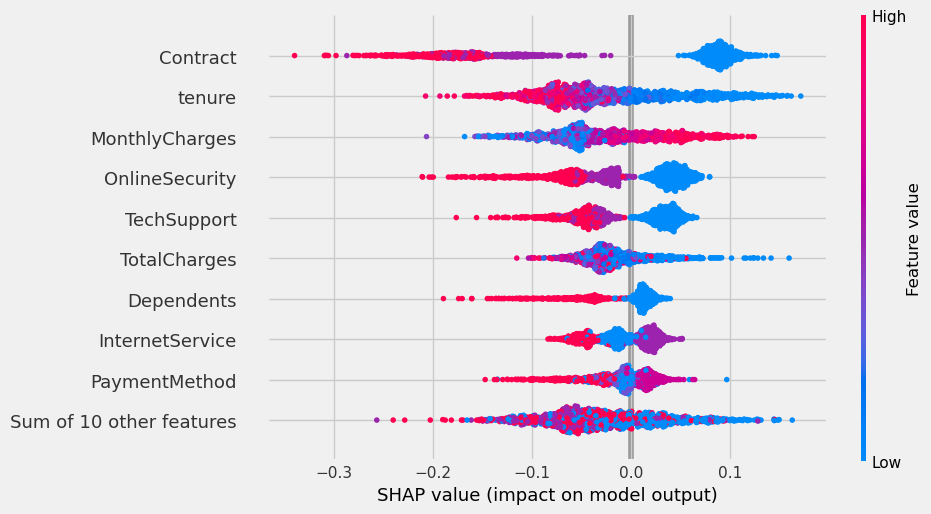

In [76]:
shap.plots.beeswarm(shap_values[:, :, 1])

## 13. Conclusion & Future Work

### Project Summary

This project successfully developed an end-to-end Machine Learning pipeline for predicting customer churn using the Telco Customer Churn dataset. The workflow included the following key stages:

* Performed comprehensive data cleaning by handling missing and hidden blank values and removing irrelevant features.
* Conducted detailed Exploratory Data Analysis (EDA) to examine feature distributions, correlations, categorical relationships, and churn patterns.
* Encoded categorical features and standardized numerical features to prepare the dataset for Machine Learning algorithms.
* Addressed class imbalance using **SMOTE** to improve the model's ability to learn from the minority class.
* Trained and compared multiple Machine Learning models, including a **Logistic Regression** baseline, **Random Forest**, and **XGBoost**, with hyperparameter tuning using **GridSearchCV**.
* Selected **Random Forest** as the final model, achieving approximately **78% test accuracy** and a **ROC-AUC score of around 0.74**.
* Saved the trained model, feature encoders, and scaler using `pickle`, and prepared the project for deployment with a Flask-based application.

### Future Improvements

Several enhancements can further improve the performance and usability of this project:

* **Feature Engineering:** Create additional features such as tenure groups, average monthly spending per subscribed service, and the total number of subscribed services.
* **Advanced Machine Learning Models:** Evaluate algorithms such as **LightGBM**, **CatBoost**, or ensemble approaches (e.g., stacking) to further improve predictive performance.
* **Decision Threshold Optimization:** Adjust the default classification threshold based on business objectives, such as maximizing recall to identify more customers at risk of churn.
* **Model Monitoring:** Implement production monitoring to detect data drift, track model performance over time, and schedule periodic retraining when necessary.
* **Full-Stack Deployment:** Containerize the Flask application using **Docker** and deploy it on a cloud platform such as **AWS**, **Google Cloud Platform (GCP)**, or **Microsoft Azure**. A user-friendly frontend (e.g., HTML/CSS/JavaScript or React) can also be developed to make the application accessible to end users.
